In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import TargetEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MaxAbsScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, SVR
from sklearn.cluster import KMeans

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import silhouette_score

In [13]:
iris = load_iris()

X = iris.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

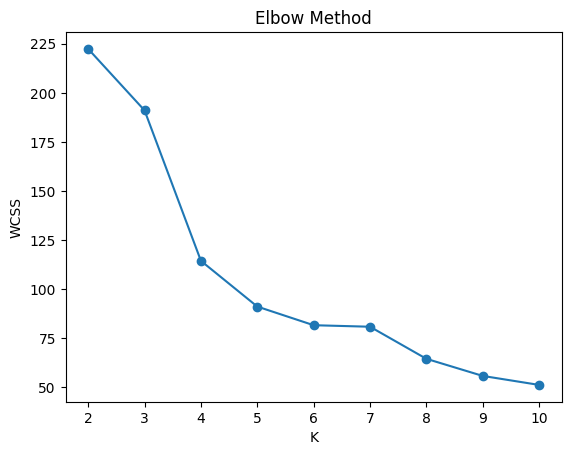

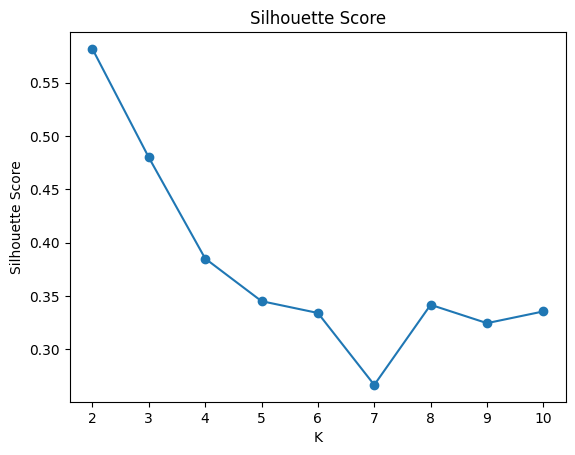

In [14]:
wcss = []
silhouette = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)

    wcss.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

plt.plot(range(2,11), wcss, marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

plt.plot(range(2,11), silhouette, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.show()

In [15]:
km = KMeans(n_clusters=3, random_state=42)

labels = km.fit_predict(X_scaled)

pd.Series(labels).value_counts().sort_index()

0    96
1    33
2    21
Name: count, dtype: int64

In [16]:
df = pd.DataFrame(X, columns=iris.feature_names)

df["Actual"] = iris.target
df["Cluster"] = labels

pd.crosstab(df["Cluster"], df["Actual"])

Actual,0,1,2
Cluster,,,
0,0,46,50
1,33,0,0
2,17,4,0
